# Lab | Week 7 | Day 5 | In God we trust, everyone else bring the data
## John Adams

## Part 1: Dataset Discovery & Exploration
### Step 1: Find and Select a Dataset

### Step 2: Load and Explore Your Dataset

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact, false_discovery_control

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
RNG = np.random.default_rng(42)

In [13]:
raw = pd.read_csv("Data/raw_global_ads_performance.csv")

print(f"shape: {raw.shape}")
print(f"columns: {raw.columns.tolist()}")
print()
print(raw.dtypes)
print()
raw.head()

shape: (1800, 14)
columns: ['date', 'platform', 'campaign_type', 'industry', 'country', 'impressions', 'clicks', 'CTR', 'CPC', 'ad_spend', 'conversions', 'CPA', 'revenue', 'ROAS']

date                 str
platform             str
campaign_type        str
industry             str
country              str
impressions        int64
clicks             int64
CTR              float64
CPC              float64
ad_spend         float64
conversions        int64
CPA              float64
revenue          float64
ROAS             float64
dtype: object



,date,platform,campaign_type,industry,country,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
0,2024-01-21,Google Ads,Search,Fintech,UAE,59886,2113,0.0353,1.26,2662.38,159,16.74,4803.43,1.80
1,2024-01-22,TikTok Ads,Search,EdTech,UK,135608,5220,0.0385,1.18,6159.60,411,14.99,64126.68,10.41
2,2024-06-15,TikTok Ads,Video,Healthcare,USA,92313,5991,0.0649,0.85,5092.35,267,19.07,10489.07,2.06
3,2024-01-02,TikTok Ads,Shopping,SaaS,Germany,83953,5935,0.0707,1.32,7834.20,296,26.47,50505.07,6.45
4,2024-02-22,TikTok Ads,Search,Healthcare,UK,91807,4489,0.0489,1.93,8663.77,107,80.97,3369.53,0.39


In [14]:
# Sample sizes per platform and date range
print(raw["platform"].value_counts())
print()
print(f"date range: {raw['date'].min()} to {raw['date'].max()}")

platform
Google Ads    720
Meta Ads      630
TikTok Ads    450
Name: count, dtype: int64

date range: 2024-01-01 to 2024-12-30


In [15]:
# Check missing values and negative values in metrics that should be non-negative
print("missing values:")
print(raw.isnull().sum())
print()
non_negative_cols = ["impressions", "clicks", "ad_spend", "conversions", "revenue"]
print("negative value counts:")
print((raw[non_negative_cols] < 0).sum())

missing values:
date             0
platform         0
campaign_type    0
industry         0
country          0
impressions      0
clicks           0
CTR              0
CPC              0
ad_spend         0
conversions      0
CPA              0
revenue          0
ROAS             0
dtype: int64

negative value counts:
impressions    0
clicks         0
ad_spend       0
conversions    0
revenue        0
dtype: int64


In [16]:
df = raw.copy()
df["date"] = pd.to_datetime(df["date"])

# Sanity check, not a fix: clicks should never exceed impressions, conversions should never exceed clicks
print(f"rows with clicks > impressions: {(df['clicks'] > df['impressions']).sum()}")
print(f"rows with conversions > clicks: {(df['conversions'] > df['clicks']).sum()}")

rows with clicks > impressions: 0
rows with conversions > clicks: 0


In [17]:
# Recompute CTR, CPA, ROAS from base counts to verify the source's precomputed columns
df["CTR_calc"] = df["clicks"] / df["impressions"]
df["CPA_calc"] = df["ad_spend"] / df["conversions"].replace(0, np.nan)
df["ROAS_calc"] = df["revenue"] / df["ad_spend"].replace(0, np.nan)

print("max abs difference vs source columns:")
print(f"  CTR:  {(df['CTR_calc'] - df['CTR']).abs().max():.6f}")
print(f"  CPA:  {(df['CPA_calc'] - df['CPA']).abs().max():.4f}")
print(f"  ROAS: {(df['ROAS_calc'] - df['ROAS']).abs().max():.4f}")

max abs difference vs source columns:
  CTR:  0.000177
  CPA:  0.0050
  ROAS: 0.0050


In [18]:
# Keep recomputed columns, drop duplicates, replace divide-by-zero inf with NaN
df["CTR"] = df["CTR_calc"]
df["CPA"] = df["CPA_calc"]
df["ROAS"] = df["ROAS_calc"]
df = df.drop(columns=["CTR_calc", "CPA_calc", "ROAS_calc"])
df = df.replace([np.inf, -np.inf], np.nan)

df["conversion_rate"] = df["conversions"] / df["clicks"]
df["profit"] = df["revenue"] - df["ad_spend"]
df["profit_margin"] = df["profit"] / df["revenue"]

df.head()

,date,platform,campaign_type,industry,country,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS,conversion_rate,profit,profit_margin
0,2024-01-21,Google Ads,Search,Fintech,UAE,59886,2113,0.035284,1.26,2662.38,159,16.744528,4803.43,1.804186,0.075248,2141.05,0.445734
1,2024-01-22,TikTok Ads,Search,EdTech,UK,135608,5220,0.038493,1.18,6159.60,411,14.986861,64126.68,10.410851,0.078736,57967.08,0.903946
2,2024-06-15,TikTok Ads,Video,Healthcare,USA,92313,5991,0.064899,0.85,5092.35,267,19.072472,10489.07,2.059770,0.044567,5396.72,0.514509
3,2024-01-02,TikTok Ads,Shopping,SaaS,Germany,83953,5935,0.070694,1.32,7834.20,296,26.466892,50505.07,6.446742,0.049874,42670.87,0.844883
4,2024-02-22,TikTok Ads,Search,Healthcare,UK,91807,4489,0.048896,1.93,8663.77,107,80.969813,3369.53,0.388922,0.023836,-5294.24,-1.571210


In [19]:
df.to_csv("Data/marketing_data.csv", index=False)

print("saved Data/marketing_data.csv")
print()
print(f"groups: {df['platform'].nunique()} ({', '.join(sorted(df['platform'].unique()))})")
print(f"sample sizes per group:")
print(df["platform"].value_counts())
print()
print(f"date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"total rows: {len(df)}")

saved Data/marketing_data.csv

groups: 3 (Google Ads, Meta Ads, TikTok Ads)
sample sizes per group:
platform
Google Ads    720
Meta Ads      630
TikTok Ads    450
Name: count, dtype: int64

date range: 2024-01-01 to 2024-12-30
total rows: 1800


### Step 2: Calculate Key Marketing Metrics

In [20]:
summary = df.groupby("platform").agg(
    impressions=("impressions", "sum"),
    clicks=("clicks", "sum"),
    conversions=("conversions", "sum"),
    ad_spend=("ad_spend", "sum"),
    revenue=("revenue", "sum"),
).reset_index()

summary["CTR"] = summary["clicks"] / summary["impressions"]
summary["conversion_rate"] = summary["conversions"] / summary["clicks"]
summary["CPA"] = summary["ad_spend"] / summary["conversions"]
summary["ROAS"] = summary["revenue"] / summary["ad_spend"]
summary["profit"] = summary["revenue"] - summary["ad_spend"]
summary["profit_margin"] = summary["profit"] / summary["revenue"]

summary = summary.replace([np.inf, -np.inf], np.nan)
summary.round(2)

,platform,impressions,clicks,conversions,ad_spend,revenue,CTR,conversion_rate,CPA,ROAS,profit,profit_margin
0,Google Ads,73801150,2936149,131098,6349268.91,22033744.95,0.04,0.04,48.43,3.47,15684476.04,0.71
1,Meta Ads,64403494,1596736,73262,2106061.67,11926045.79,0.02,0.05,28.75,5.66,9819984.12,0.82
2,TikTok Ads,47049590,2599931,122452,2653418.51,20223540.07,0.06,0.05,21.67,7.62,17570121.56,0.87


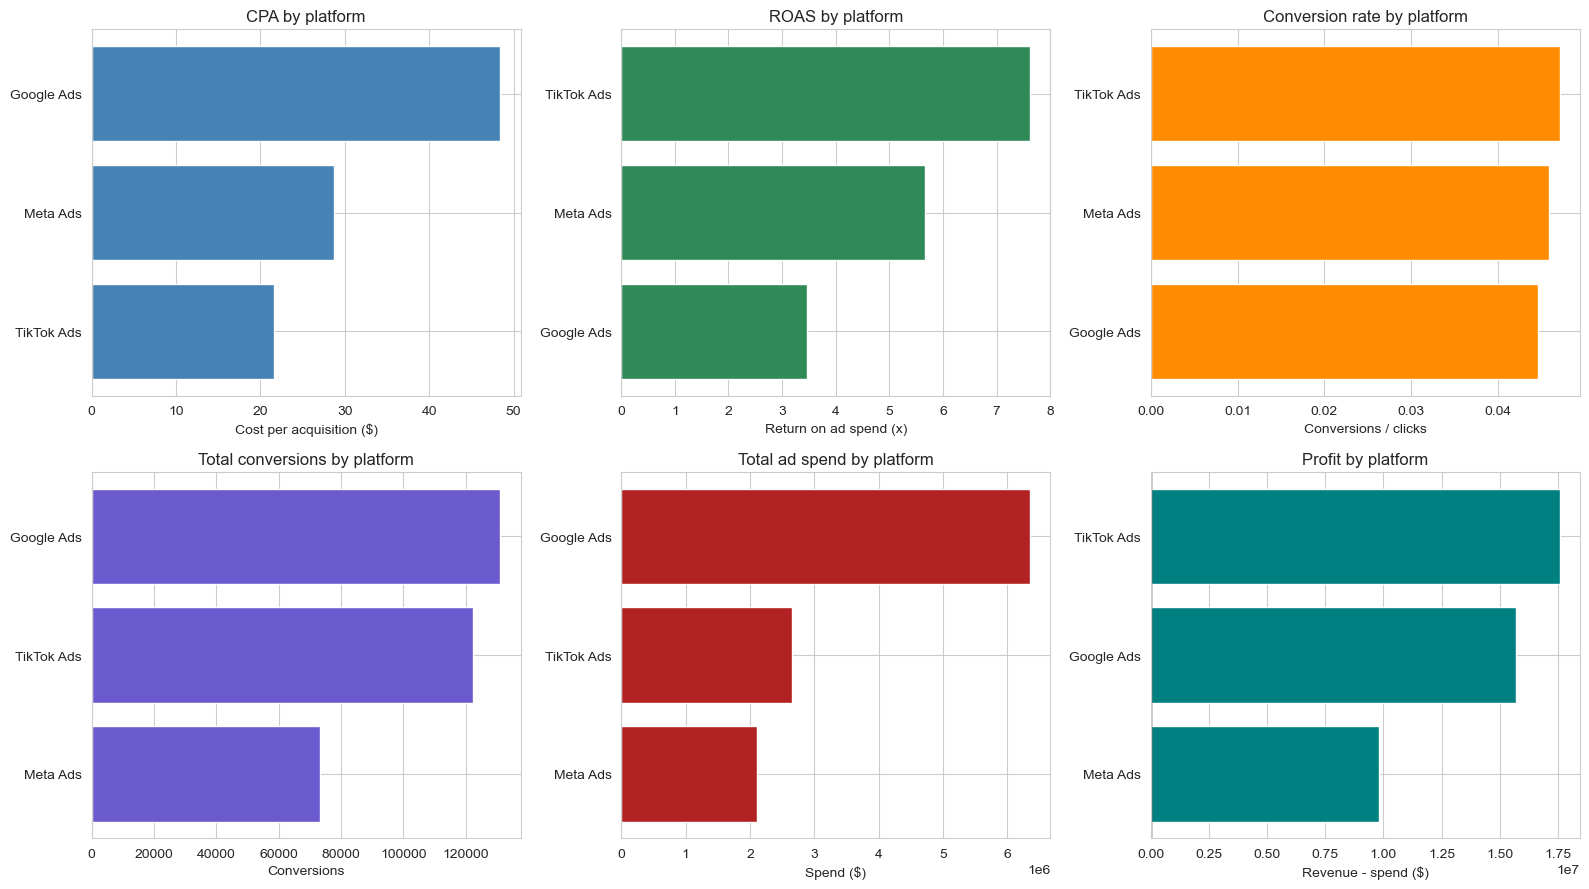

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

summary_sorted = summary.sort_values("CPA")
axes[0, 0].barh(summary_sorted["platform"], summary_sorted["CPA"], color="steelblue")
axes[0, 0].set_title("CPA by platform")
axes[0, 0].set_xlabel("Cost per acquisition ($)")

summary_sorted = summary.sort_values("ROAS")
axes[0, 1].barh(summary_sorted["platform"], summary_sorted["ROAS"], color="seagreen")
axes[0, 1].set_title("ROAS by platform")
axes[0, 1].set_xlabel("Return on ad spend (x)")

summary_sorted = summary.sort_values("conversion_rate")
axes[0, 2].barh(summary_sorted["platform"], summary_sorted["conversion_rate"], color="darkorange")
axes[0, 2].set_title("Conversion rate by platform")
axes[0, 2].set_xlabel("Conversions / clicks")

summary_sorted = summary.sort_values("conversions")
axes[1, 0].barh(summary_sorted["platform"], summary_sorted["conversions"], color="slateblue")
axes[1, 0].set_title("Total conversions by platform")
axes[1, 0].set_xlabel("Conversions")

summary_sorted = summary.sort_values("ad_spend")
axes[1, 1].barh(summary_sorted["platform"], summary_sorted["ad_spend"], color="firebrick")
axes[1, 1].set_title("Total ad spend by platform")
axes[1, 1].set_xlabel("Spend ($)")

summary_sorted = summary.sort_values("profit")
axes[1, 2].barh(summary_sorted["platform"], summary_sorted["profit"], color="teal")
axes[1, 2].axvline(0, color="black", linewidth=1)
axes[1, 2].set_title("Profit by platform")
axes[1, 2].set_xlabel("Revenue - spend ($)")

plt.tight_layout()
plt.savefig("Outputs/group_metrics_overview.png", dpi=150)
plt.show()

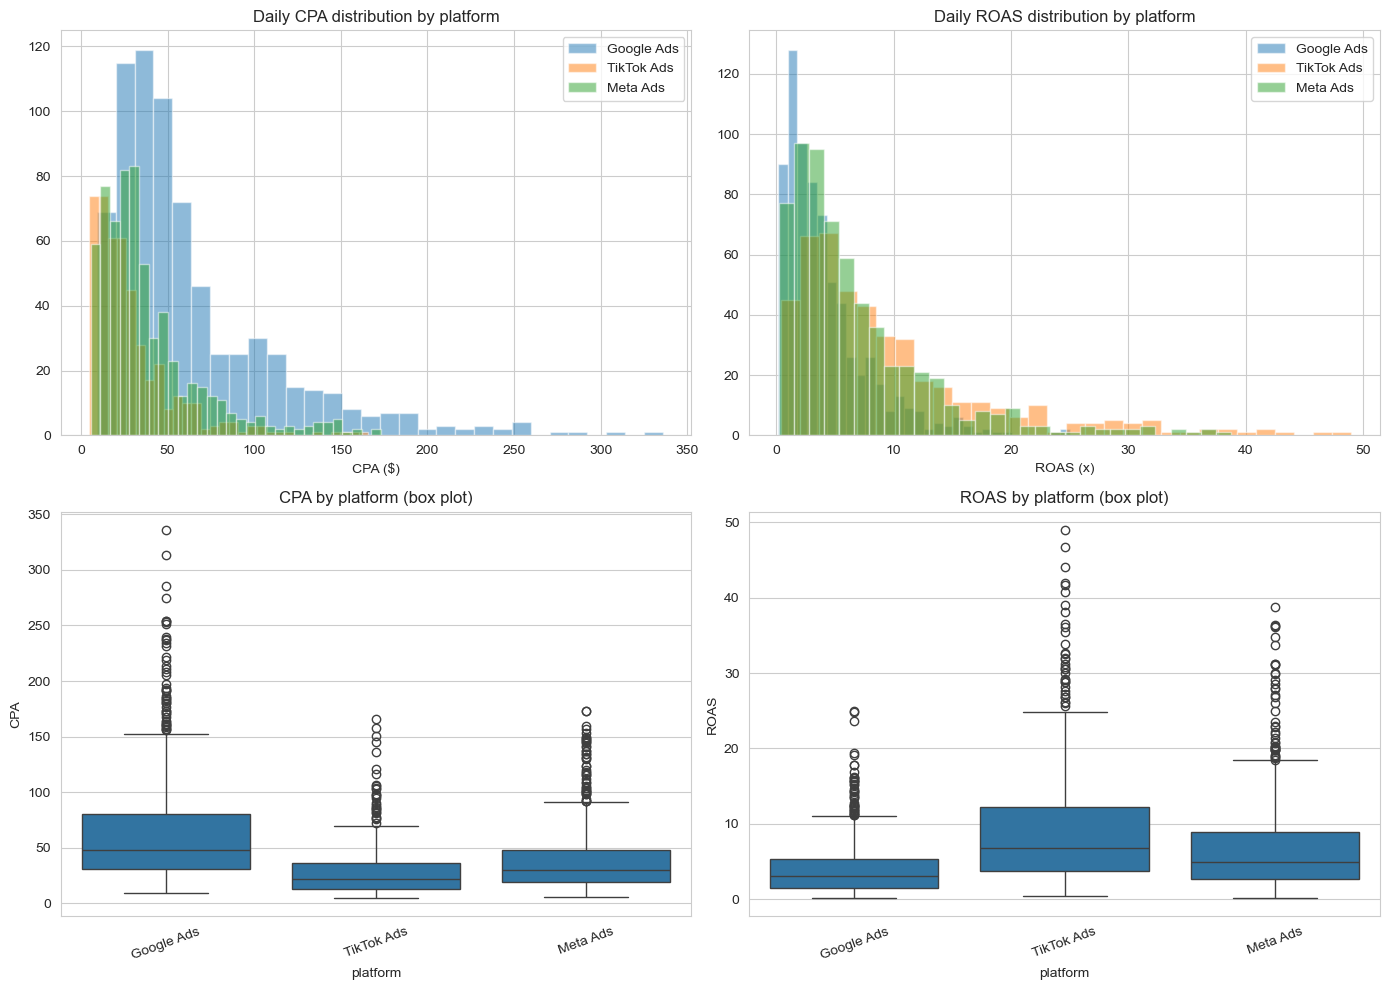

In [22]:
daily = df.copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for platform in daily["platform"].unique():
    subset = daily[daily["platform"] == platform]
    axes[0, 0].hist(subset["CPA"].dropna(), bins=30, alpha=0.5, label=platform)
axes[0, 0].set_title("Daily CPA distribution by platform")
axes[0, 0].set_xlabel("CPA ($)")
axes[0, 0].legend()

for platform in daily["platform"].unique():
    subset = daily[daily["platform"] == platform]
    axes[0, 1].hist(subset["ROAS"].dropna(), bins=30, alpha=0.5, label=platform)
axes[0, 1].set_title("Daily ROAS distribution by platform")
axes[0, 1].set_xlabel("ROAS (x)")
axes[0, 1].legend()

sns.boxplot(data=daily, x="platform", y="CPA", ax=axes[1, 0])
axes[1, 0].set_title("CPA by platform (box plot)")
axes[1, 0].tick_params(axis="x", rotation=20)

sns.boxplot(data=daily, x="platform", y="ROAS", ax=axes[1, 1])
axes[1, 1].set_title("ROAS by platform (box plot)")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("Outputs/group_distributions.png", dpi=150)
plt.show()